# Diagnostics! 

#### Importing functions

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
import sys, os
sys.path.append(os.path.abspath("../../"))    # Calling the HorizonFinder.py source code from src
from src.nosym_snes import nosym

#### Data produced & Plots

In [4]:
with h5py.File("./data/BH1_horizon.h5", 'r') as f:
    theta1 = f['theta'][:]
    phi1   = f['phi'][:]
    h1     = f['h'][:]          # (Ntheta, Nphi) in local frame centred on BH1

with h5py.File("./data/BH2_horizon.h5", 'r') as f:
    theta2 = f['theta'][:]
    phi2   = f['phi'][:]
    h2     = f['h'][:]          # local frame centred on BH2

with h5py.File("./data/horizon_common.h5", 'r') as f:
    theta_c = f['theta'][:]
    phi_c   = f['phi'][:]
    h_c     = f['h'][:]         # common horizon in global frame

#### Cross-Section Plot

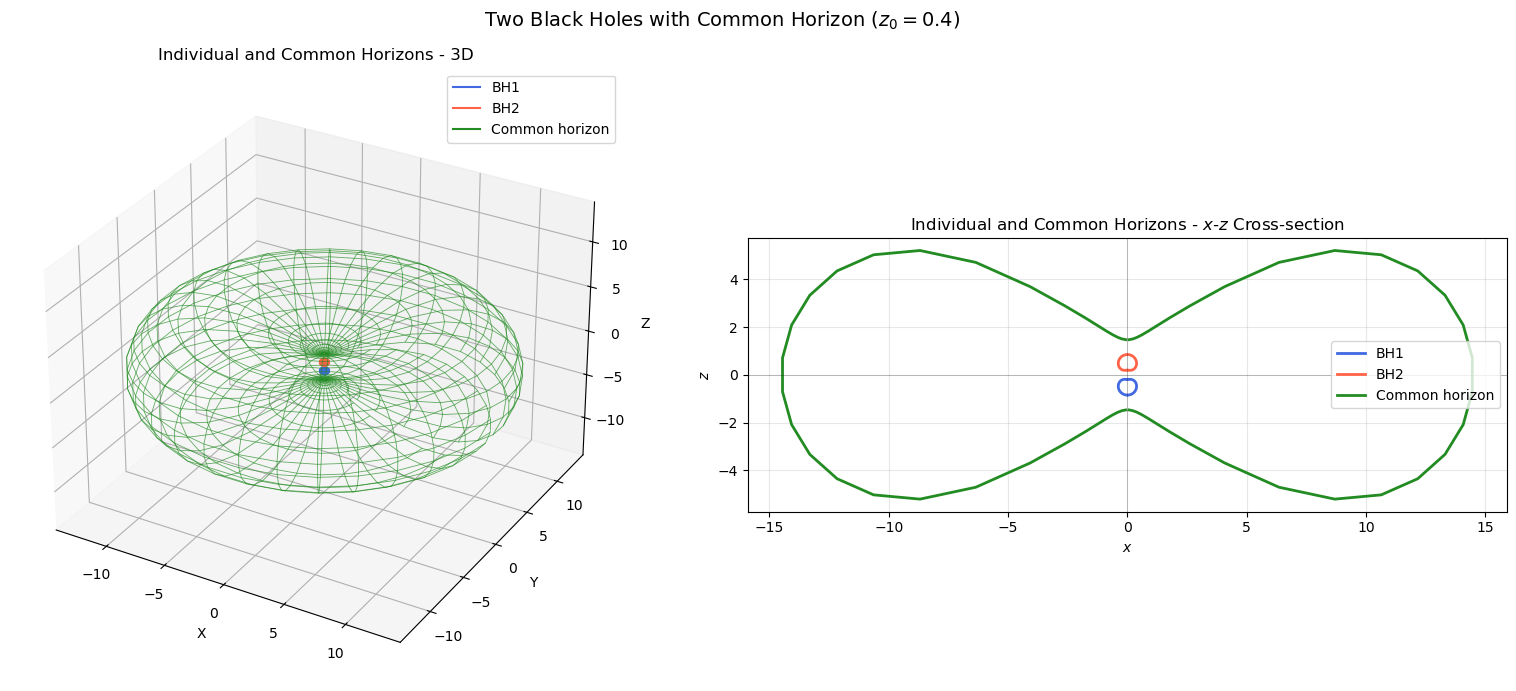

In [5]:
# Physical parameters from input_TwoBH.py
M1, M2 = 1.0, 1.0
sep = 0.2
z0 = sep * (M1 + M2)   # = 1.0  ->  BH1 at z=-z0, BH2 at z=+z0

# Global Cartesian coords for the individual horizons
THETA1, PHI1 = np.meshgrid(theta1, phi1, indexing='ij')
X1 = h1 * np.sin(THETA1) * np.cos(PHI1)
Y1 = h1 * np.sin(THETA1) * np.sin(PHI1)
Z1 = h1 * np.cos(THETA1) - z0

THETA2, PHI2 = np.meshgrid(theta2, phi2, indexing='ij')
X2 = h2 * np.sin(THETA2) * np.cos(PHI2)
Y2 = h2 * np.sin(THETA2) * np.sin(PHI2)
Z2 = h2 * np.cos(THETA2) + z0

# Common horizon is already defined in the global frame
THETA_C, PHI_C = np.meshgrid(theta_c, phi_c, indexing='ij')
XC = h_c * np.sin(THETA_C) * np.cos(PHI_C)
YC = h_c * np.sin(THETA_C) * np.sin(PHI_C)
ZC = h_c * np.cos(THETA_C)

def xz_section(h, theta, phi, z_centre=0.0):
    idx0 = 0
    idx_pi = len(phi) // 2
    x_r = h[:, idx0] * np.sin(theta)
    z_r = h[:, idx0] * np.cos(theta) + z_centre
    x_l = -h[:, idx_pi] * np.sin(theta)
    z_l = h[:, idx_pi] * np.cos(theta) + z_centre
    return x_r, z_r, x_l, z_l

x1r, z1r, x1l, z1l = xz_section(h1, theta1, phi1, -z0)
x2r, z2r, x2l, z2l = xz_section(h2, theta2, phi2, +z0)
xcr, zcr, xcl, zcl = xz_section(h_c, theta_c, phi_c, 0.0)

fig = plt.figure(figsize=(16, 7))

# Left: BH1, BH2, and the common horizon on one 3D plot
ax3d = fig.add_subplot(121, projection='3d')
ax3d.plot_wireframe(X1, Y1, Z1, color='royalblue', linewidth=0.5, alpha=0.6)
ax3d.plot_wireframe(X2, Y2, Z2, color='tomato', linewidth=0.5, alpha=0.6)
ax3d.plot_wireframe(XC, YC, ZC, color='forestgreen', linewidth=0.6, alpha=0.7)
ax3d.set_xlabel('X')
ax3d.set_ylabel('Y')
ax3d.set_zlabel('Z')
ax3d.set_title('Individual and Common Horizons - 3D')
max_r = max(
    np.max(np.abs(X1)), np.max(np.abs(X2)), np.max(np.abs(XC)),
    np.max(np.abs(Z1)), np.max(np.abs(Z2)), np.max(np.abs(ZC)),
)
ax3d.set_xlim([-max_r, max_r])
ax3d.set_ylim([-max_r, max_r])
ax3d.set_zlim([-max_r, max_r])
from matplotlib.lines import Line2D
ax3d.legend(handles=[
    Line2D([0], [0], color='royalblue', label='BH1'),
    Line2D([0], [0], color='tomato', label='BH2'),
    Line2D([0], [0], color='forestgreen', label='Common horizon'),
])

# Right: all x-z cross-sections on one 2D plot
ax2d = fig.add_subplot(122)
ax2d.plot(x1r, z1r, color='royalblue', lw=2)
ax2d.plot(x1l, z1l, color='royalblue', lw=2, label='BH1')
ax2d.plot(x2r, z2r, color='tomato', lw=2)
ax2d.plot(x2l, z2l, color='tomato', lw=2, label='BH2')
ax2d.plot(xcr, zcr, color='forestgreen', lw=2)
ax2d.plot(xcl, zcl, color='forestgreen', lw=2, label='Common horizon')
ax2d.axhline(0, color='k', lw=0.5, alpha=0.3)
ax2d.axvline(0, color='k', lw=0.5, alpha=0.3)
ax2d.set_xlabel(r'$x$')
ax2d.set_ylabel(r'$z$')
ax2d.set_title(r'Individual and Common Horizons - $x$-$z$ Cross-section')
ax2d.set_aspect('equal')
ax2d.grid(True, alpha=0.3)
ax2d.legend()

plt.suptitle(f'Two Black Holes with Common Horizon ($z_0 = {z0}$)', fontsize=14)
plt.tight_layout()
plt.show()